### Read SNOWPACK Output at Tram with HRRR-AK

created by Cassie Lumbrazo\
last updated: April 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/tram'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [3]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [4]:
ds_snowpack, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_tram_WY2025_base.smet")

/tmp/ipykernel_3402972/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


### Open Tram Observations

In [10]:
# # open observations
tram_file = '/hdd/snow_hydrology/met_station/tram/tram_met_WY2025_clean_temporary.csv' # created in script 1_met_tram.ipynb
tram_obs = pd.read_csv(tram_file, parse_dates=['datetime'], index_col='datetime')
tram_obs


,Station_ID,Date_Time,air_temp_set_1,relative_humidity_set_1,wind_speed_set_1,wind_direction_set_1,wind_gust_set_1,snow_depth_set_1,solar_radiation_set_1,precip_accum_set_1,volt_set_1,snow_interval_set_1,wind_chill_set_1d,wind_cardinal_direction_set_1d,heat_index_set_1d,dew_point_temperature_set_1d,snow_depth_set_1_inches
datetime,,,,,,,,,,,,,,,,,
2024-10-01 00:00:00+00:00,JTMA2,2024-10-01T00:00:00Z,4.41,82.90,0.0,NaN,0.0,151.892,0.0,3262.884,13.43,1234.948,NaN,NaN,NaN,1.72,5.98
2024-10-01 01:00:00+00:00,JTMA2,2024-10-01T01:00:00Z,4.78,82.60,0.0,NaN,0.0,148.082,0.0,3263.900,13.44,1231.900,NaN,NaN,NaN,2.03,5.83
2024-10-01 02:00:00+00:00,JTMA2,2024-10-01T02:00:00Z,4.44,87.00,0.0,NaN,0.0,144.526,0.0,3263.900,13.43,1252.982,NaN,NaN,NaN,2.44,5.69
2024-10-01 03:00:00+00:00,JTMA2,2024-10-01T03:00:00Z,3.90,91.80,0.0,NaN,0.0,151.130,0.0,3265.932,13.44,1256.030,NaN,NaN,NaN,2.67,5.95
2024-10-01 04:00:00+00:00,JTMA2,2024-10-01T04:00:00Z,3.76,90.00,0.0,NaN,0.0,147.828,0.0,3267.964,13.43,1276.096,NaN,NaN,NaN,2.25,5.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-29 20:00:00+00:00,JTMA2,2025-09-29T20:00:00Z,8.73,45.18,0.0,0.0,0.0,2975.102,0.0,NaN,13.44,1055.116,NaN,N,NaN,-2.60,117.13
2025-09-29 21:00:00+00:00,JTMA2,2025-09-29T21:00:00Z,9.21,42.31,0.0,0.0,0.0,2971.038,0.0,NaN,13.44,1051.052,NaN,N,NaN,-3.05,116.97
2025-09-29 22:00:00+00:00,JTMA2,2025-09-29T22:00:00Z,9.00,45.49,0.0,0.0,0.0,2960.878,0.0,NaN,13.44,1030.986,NaN,N,NaN,-2.26,116.57


Text(0, 0.5, 'snow depth (cm)')

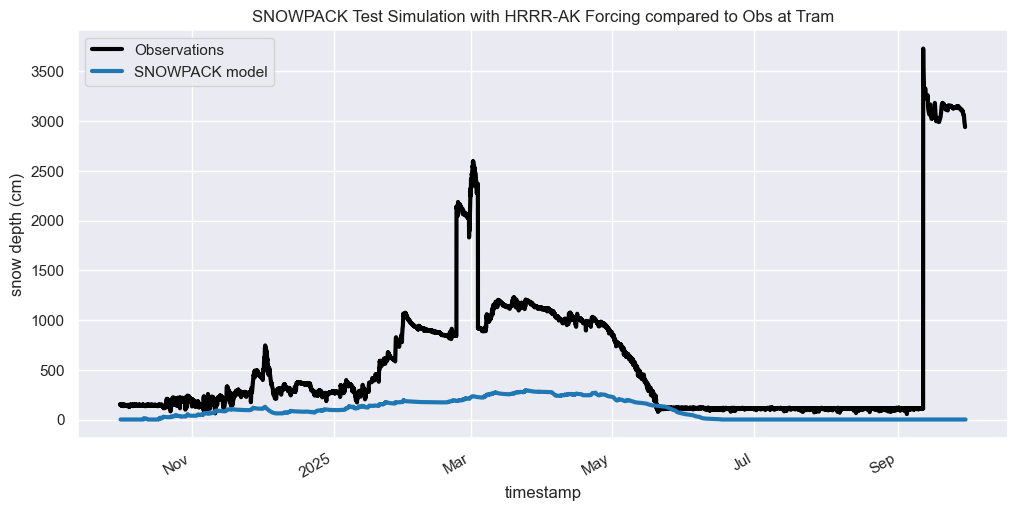

In [12]:
tram_obs.snow_depth_set_1.plot(label = 'Observations', linewidth = 3, color='black')
ds_snowpack.HS_mod.plot(label = 'SNOWPACK model', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Test Simulation with HRRR-AK Forcing compared to Obs at Tram')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

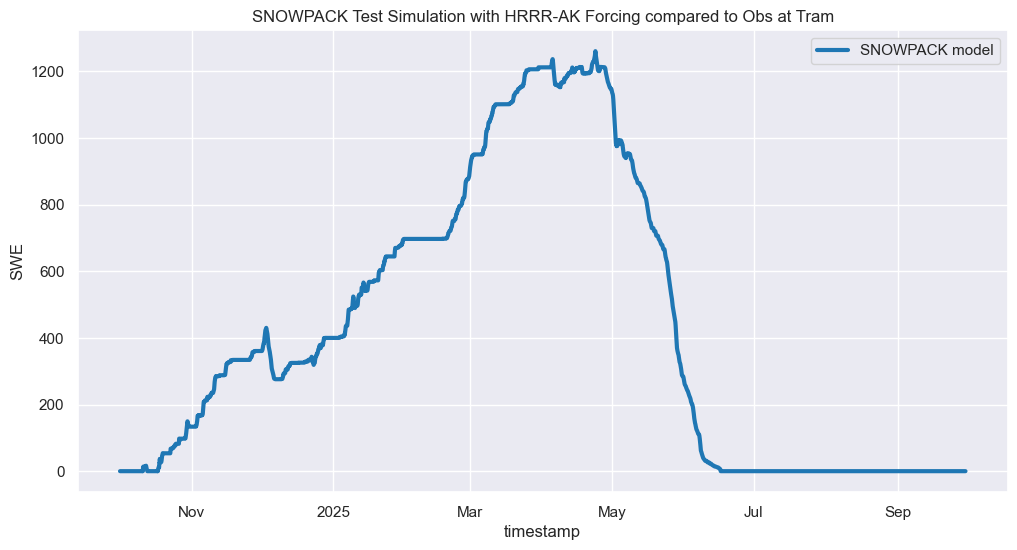

In [7]:
ds_snowpack.SWE.plot(label = 'SNOWPACK model', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Test Simulation with HRRR-AK Forcing compared to Obs at Tram')
plt.legend()